# Mirage-19 Traffic Classification with 1D-CNN

This notebook implements a deep learning pipeline to classify mobile application traffic using the **Mirage-19** dataset. 

## Project Overview
- **Goal**: Classify mobile apps based on the first 36 packets of a flow.
- **Input**: Sequence of 36 packets with 4 features (Direction, Payload Length, TCP Window, Inter-Arrival Time).
- **Model**: 1D Convolutional Neural Network (1D-CNN) implemented in PyTorch.
- **Hardware**: Optimized for execution on GPU (RTX 3070Ti).


In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from collections import Counter
import time
import copy
import multiprocessing
import os

# Configuration
DATA_PATH = "dataset/mirage2019_LOPEZ_lopez_lopez_36P_4F_APP_xST_PAD_metadata.pickle"

RANDOM_SEED = 2025

## Load Data
Loading the preprocessed pickle file containing biflows and labels.

In [2]:
print("Loading dataset...")
with open(DATA_PATH, "rb") as f:
    X_raw = np.array(pickle.load(f), dtype=np.float32) # Convert to numpy array
    y_raw = np.array(pickle.load(f)) # Convert to numpy array

print(f"Data shape: {X_raw.shape}")
print(f"Labels shape: {len(y_raw)}")

# Example sample
example_sample = 7000
print("\nExample Sample (First 5 packets):\n", X_raw[example_sample][:5])
print("Example Label:", y_raw[example_sample])


Loading dataset...
Data shape: (96999, 36, 4)
Labels shape: 96999

Example Sample (First 5 packets):
 [[0.0000000e+00 2.0300000e+02 3.4300000e+02 0.0000000e+00]
 [1.0000000e+00 1.4480000e+03 2.3500000e+02 2.9068947e-02]
 [1.0000000e+00 1.4480000e+03 2.3500000e+02 5.9604645e-06]
 [1.0000000e+00 1.2000000e+03 2.3500000e+02 4.0531158e-06]
 [1.0000000e+00 1.4480000e+03 2.3500000e+02 1.1920929e-05]]
Example Label: AccuWeather


## Data exploration
Checking the mean number of packets per flow. If dst is -1, it is a padding packet.

In [3]:
def count_packets(flow):
    """Calcola il numero di pacchetti validi in un singolo flusso."""
    # Usa la logica ottimizzata: trova l'indice del primo -1, altrimenti usa la lunghezza
    return next((i for i, packet in enumerate(flow) if packet[0] == -1), len(flow))

# Esempio
print("Example sample packet len: ", count_packets(X_raw[example_sample]))

Example sample packet len:  36


In [4]:
X_n_packets = []

X_dir_trimmed = []
X_payloadLen_trimmed = []
X_tcpWin_trimmed = []
X_iat_trimmed = []

for i, flow in enumerate(X_raw):
    num_packets = count_packets(flow)
    X_n_packets.append(num_packets)
    
    # Estraiamo i dati 'trimmati' e li aggiungiamo alle nuove liste
    # Utilizziamo le colonne originali di X_raw
    X_dir_trimmed.append(flow[:num_packets, 0])
    X_payloadLen_trimmed.append(flow[:num_packets, 1].sum())
    X_tcpWin_trimmed.append(flow[:num_packets, 2].mean())
    X_iat_trimmed.append(flow[:num_packets, 3].mean())

X_n_packets = np.array(X_n_packets)

print("Example sample packet length:", X_n_packets[example_sample])

print("Example sample direction:", X_dir_trimmed[example_sample])
print("Example sample payload length:", X_payloadLen_trimmed[example_sample])
print("Example sample TCP window:", X_tcpWin_trimmed[example_sample])
print("Example sample IAT:", X_iat_trimmed[example_sample])


Example sample packet length: 36
Example sample direction: [0. 1. 1. 1. 1. 1. 1. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Example sample payload length: 46287.0
Example sample TCP window: 253.55556
Example sample IAT: 0.013138857


In [5]:
print("Mean packets per flow: ", np.mean(X_n_packets))
print("Standard deviation packets per flow: ", np.std(X_n_packets))

Mean packets per flow:  18.687182342086
Standard deviation packets per flow:  12.253074224658414


Analyzing class distribution and feature statistics.

C:\Users\Matte\AppData\Local\Temp\ipykernel_52732\3184034346.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_counts.index, y=df_counts['count'], palette='viridis')


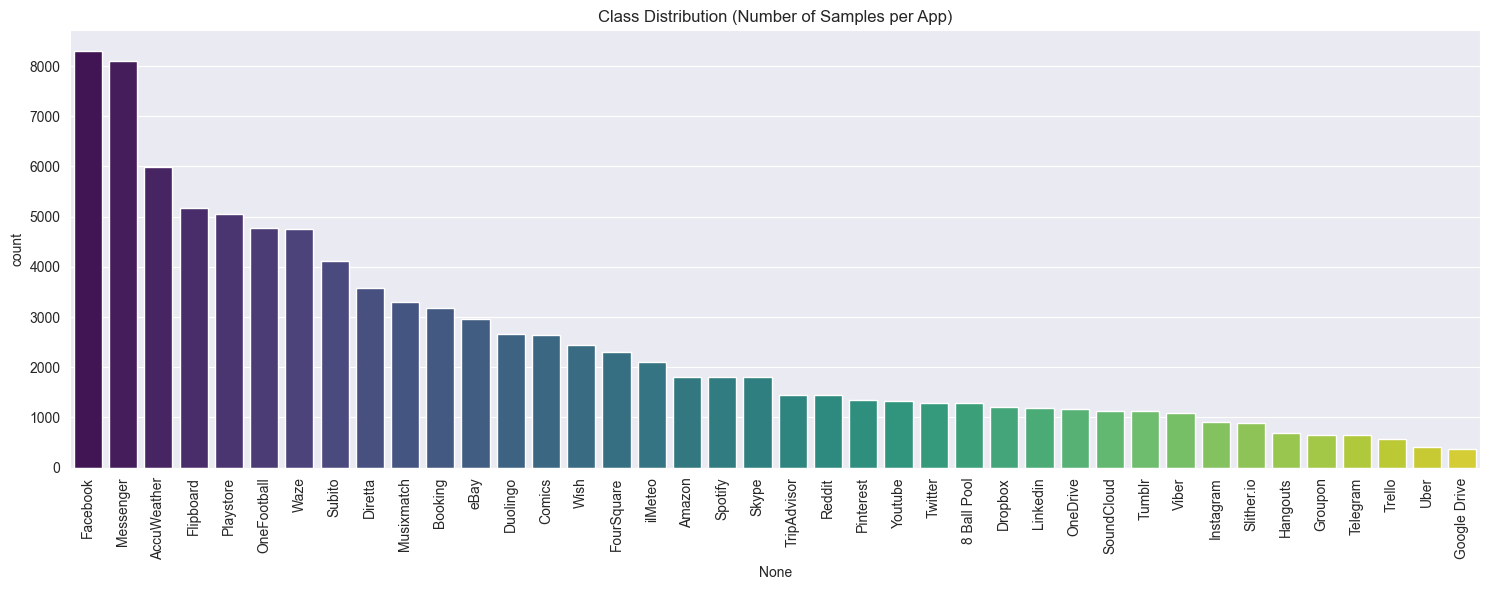

In [6]:
# Class Distribution
counts = Counter(y_raw)
df_counts = pd.DataFrame.from_dict(counts, orient='index', columns=['count']).sort_values('count', ascending=False)

plt.figure(figsize=(15, 6))
sns.barplot(x=df_counts.index, y=df_counts['count'], palette='viridis')
plt.xticks(rotation=90)
plt.title("Class Distribution (Number of Samples per App)")
plt.tight_layout()
plt.show()

Checking, for each class, the mean number of packets per flow.

C:\Users\Matte\AppData\Local\Temp\ipykernel_52732\3956050350.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


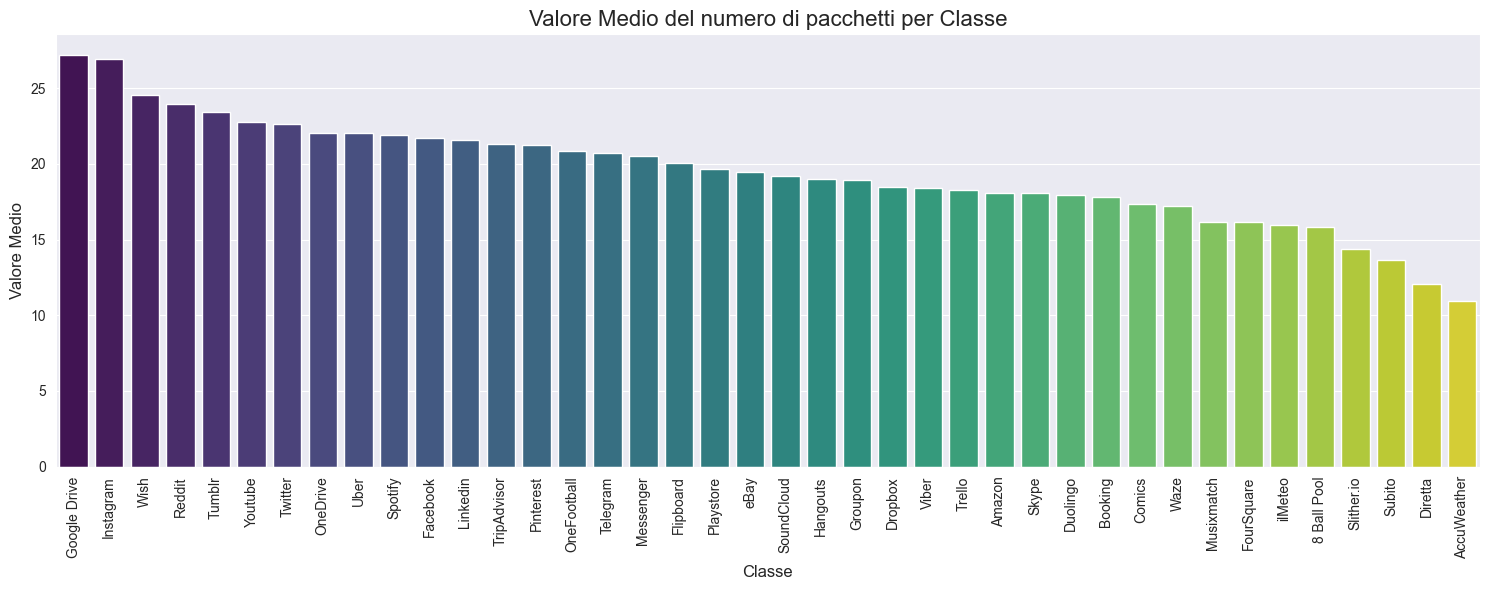

In [7]:
# Mean packet pre flow
data = {
    'y': y_raw,
    'x': X_n_packets,
    # 'dir': X_dir,
    'payloadLen': X_payloadLen_trimmed,
    'tcpWin': X_tcpWin_trimmed,
    'iat': X_iat_trimmed,
}
df = pd.DataFrame(data)

df_media = df.groupby('y')['x'].mean().reset_index()
df_media.columns = ['Etichetta', 'Media_X']
df_media = df_media.sort_values('Media_X', ascending=False)


plt.figure(figsize=(15, 6))

sns.barplot(
    x='Etichetta', 
    y='Media_X', 
    data=df_media, 
    palette='viridis' # Manteniamo la palette del tuo codice
)

plt.xticks(rotation=90)
plt.title("Valore Medio del numero di pacchetti per Classe", fontsize=16)
plt.xlabel("Classe", fontsize=12)
plt.ylabel("Valore Medio", fontsize=12)
plt.tight_layout()
plt.show()

Standard Deviation for each class

C:\Users\Matte\AppData\Local\Temp\ipykernel_52732\728721901.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


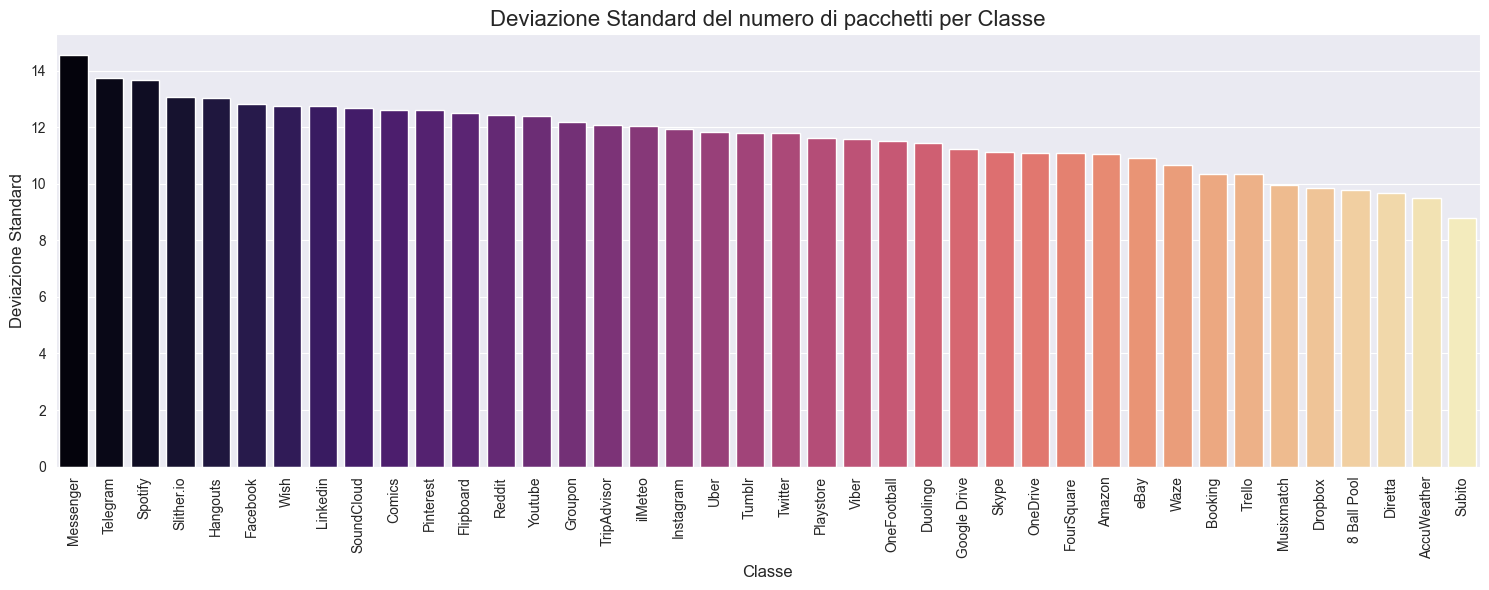

In [8]:
df_std = df.groupby('y')['x'].std().reset_index()

# Rinomina le colonne
df_std.columns = ['Etichetta', 'Deviazione_Standard_X']

# Ordina in base alla Deviazione Standard in modo decrescente
df_std = df_std.sort_values('Deviazione_Standard_X', ascending=False)


# --- 3. Visualizzazione con Seaborn ---
plt.figure(figsize=(15, 6))

# Usa sns.barplot con il DataFrame df_std ordinato
sns.barplot(
    x='Etichetta', 
    y='Deviazione_Standard_X', 
    data=df_std, 
    palette='magma' # Ho cambiato la palette per differenziare dal grafico della media
)

# Impostazioni finali del grafico
plt.xticks(rotation=90)
plt.title("Deviazione Standard del numero di pacchetti per Classe", fontsize=16)
plt.xlabel("Classe", fontsize=12)
plt.ylabel("Deviazione Standard", fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
df_analisi_completa = df.groupby('y')['x'].agg(
    [
        'mean',       # Media
        'std',        # Deviazione Standard
        'median',     # Mediana
        'min',        # Minimo
        'max',        # Massimo
        pd.Series.skew, # Asimmetria (Skewness)
        pd.Series.kurt  # Curtosi (Kurtosis)
    ]
).reset_index()

print(df_analisi_completa)

               y       mean        std  median  min  max      skew      kurt
0    8 Ball Pool  15.811572   9.779237    11.0    4   36  1.352194  0.179946
1    AccuWeather  10.971433   9.504430     8.0    1   36  1.587476  1.765242
2         Amazon  18.069023  11.038716    14.0    3   36  0.664502 -1.091191
3        Booking  17.809119  10.352715    13.0    3   36  0.867613 -0.817933
4         Comics  17.317304  12.618140    11.0    2   36  0.640758 -1.378705
5        Diretta  12.054469   9.663728    11.0    1   36  1.308275  1.028351
6        Dropbox  18.472772   9.847479    14.0    6   36  0.868336 -0.785763
7       Duolingo  17.956048  11.433185    13.0    3   36  0.654832 -1.186001
8       Facebook  21.721157  12.813665    20.0    1   36 -0.053589 -1.653585
9      Flipboard  20.029179  12.485822    17.0    1   36  0.208098 -1.577447
10    FourSquare  16.153946  11.077646    11.0    1   36  0.950814 -0.640786
11  Google Drive  27.188366  11.217941    36.0    2   36 -0.725030 -1.151377

## Payload length

In [8]:
df_analisi_completa = df.groupby('y')['payloadLen'].agg(
    [
        'mean',       # Media
        'std',        # Deviazione Standard
        'median',     # Mediana
        'min',        # Minimo
        'max',        # Massimo
        pd.Series.skew, # Asimmetria (Skewness)
        pd.Series.kurt  # Curtosi (Kurtosis)
    ]
).reset_index()

print(df_analisi_completa)

               y          mean           std   median     min      max  \
0    8 Ball Pool  12240.539062  13195.256332   6543.0  1004.0  49913.0   
1    AccuWeather   7683.302246  11310.789170   4270.0   187.0  51020.0   
2         Amazon  14165.049805  11932.854570   9146.0   436.0  45900.0   
3        Booking  13858.345703  14282.984460   7022.5   472.0  50910.0   
4         Comics  17373.707031  18300.389435   7281.0   442.0  51026.0   
5        Diretta   6917.666016  11269.496697   1838.0     7.0  50868.0   
6        Dropbox  12554.707031  11434.064858   7962.0  1495.0  47514.0   
7       Duolingo  13246.583008  13635.427545   7239.5   606.0  49972.0   
8       Facebook  16415.306641  15437.970035   8284.0   187.0  51602.0   
9      Flipboard  17890.300781  16403.266846   8651.0     7.0  51574.0   
10    FourSquare  12471.774414  13507.983660   6596.0   517.0  48678.0   
11  Google Drive  21181.707031  15318.154481  16591.0   673.0  46898.0   
12       Groupon  16446.298828  16061.

## TCPWin

In [41]:
df_analisi_completa = df.groupby('y')['tcpWin'].agg(
    [
        'mean',       # Media
        'std',        # Deviazione Standard
        'median',     # Mediana
        'min',        # Minimo
        'max',        # Massimo
        pd.Series.skew, # Asimmetria (Skewness)
        pd.Series.kurt  # Curtosi (Kurtosis)
    ]
).reset_index()

print(df_analisi_completa)

               y          mean           std       median         min  \
0    8 Ball Pool    580.827332   4062.203369   212.000000   57.194443   
1    AccuWeather   1088.794922   5420.201660   271.333344   11.000000   
2         Amazon    421.393707   1436.010864   278.666656  142.361115   
3        Booking    663.767395   2706.612305   218.000000   66.888885   
4         Comics    343.183990    912.438232   272.000000  129.111115   
5        Diretta  16777.210938  21940.666016   219.300003   66.888885   
6        Dropbox    183.957550     47.164272   172.857147   83.750000   
7       Duolingo    657.493408   4469.193359   234.666672   66.888885   
8       Facebook    686.662109   3938.767822   203.694443   32.333332   
9      Flipboard   1263.468140   5726.407715   228.285721   11.000000   
10    FourSquare    207.322571     64.359825   213.375000   64.944443   
11  Google Drive    293.327393     25.232128   292.647064  145.916672   
12       Groupon    295.357605    103.056129   289.

## IAT

In [42]:
df_analisi_completa = df.groupby('y')['iat'].agg(
    [
        'mean',       # Media
        'std',        # Deviazione Standard
        'median',     # Mediana
        'min',        # Minimo
        'max',        # Massimo
        pd.Series.skew, # Asimmetria (Skewness)
        pd.Series.kurt  # Curtosi (Kurtosis)
    ]
).reset_index()

print(df_analisi_completa)

               y      mean        std    median  min        max      skew  \
0    8 Ball Pool  2.525934   3.924149  0.769231  0.0  42.714287  3.226881   
1    AccuWeather  1.283261   3.154007  0.071429  0.0  35.142857  5.754534   
2         Amazon  2.593693   4.355368  0.142857  0.0  42.857143  2.369904   
3        Booking  2.559197   4.214447  1.000000  0.0  48.000000  3.677788   
4         Comics  1.107391   2.499294  0.166667  0.0  29.571428  4.835917   
5        Diretta  0.710174   2.961404  0.000000  0.0  30.000000  6.110547   
6        Dropbox  2.278329   3.317777  1.666667  0.0  37.500000  4.446205   
7       Duolingo  1.001296   3.422859  0.019500  0.0  29.900000  6.038463   
8       Facebook  3.057660   5.493788  0.257538  0.0  59.222221  3.127492   
9      Flipboard  1.782662   4.292051  0.019222  0.0  62.500000  4.838171   
10    FourSquare  1.836385   3.770691  0.166667  0.0  29.900000  3.520371   
11  Google Drive  1.706136   3.928122  0.029028  0.0  17.071428  2.529986   